In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-vs-bike-classification-dataset' dataset.
Path to dataset files: /kaggle/input/car-vs-bike-classification-dataset


In [8]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory ({path}):\n{os.listdir(path)}")

# Correctly identify the base path for the dataset content
dataset_base_path = os.path.join(path, 'Car-Bike-Dataset')

# Check if 'Car-Bike-Dataset' exists and list its contents
if os.path.exists(dataset_base_path):
    print(f"\nContents of the '{os.path.basename(dataset_base_path)}' directory ({dataset_base_path}):\n{os.listdir(dataset_base_path)}")
    # Further checks can be added here if needed, e.g., for 'Train' and 'Test' subdirectories
else:
    print(f"\n'Car-Bike-Dataset' directory not found at {dataset_base_path}. Please verify the dataset structure.")


Contents of the dataset directory (/kaggle/input/car-vs-bike-classification-dataset):
['Car-Bike-Dataset']

Contents of the 'Car-Bike-Dataset' directory (/kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset):
['Car', 'Bike']


In [9]:
import os
from sklearn.model_selection import train_test_split

# Define the base path to the dataset, which was identified in the previous cell
# dataset_base_path is '/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset'

# Initialize lists to store image paths and labels
all_image_paths = []
all_image_labels = []

# Iterate through each category (Car, Bike)
for category in ['Car', 'Bike']:
    category_path = os.path.join(dataset_base_path, category)
    for img_name in os.listdir(category_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(category_path, img_name))
            all_image_labels.append(category)

print(f"Total images found: {len(all_image_paths)}")
print(f"Example image path: {all_image_paths[0] if all_image_paths else 'N/A'}")
print(f"Example image label: {all_image_labels[0] if all_image_labels else 'N/A'}")

Total images found: 3996
Example image path: /kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset/Car/Car (1613).jpeg
Example image label: Car


In [10]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    all_image_paths, all_image_labels, test_size=0.2, random_state=42, stratify=all_image_labels
)

print(f"Number of training images: {len(X_train)}")
print(f"Number of testing images: {len(X_test)}")
print("Dataset split successfully!")

Number of training images: 3196
Number of testing images: 800
Dataset split successfully!


## Check GPU Availability

In [11]:
import tensorflow as tf

# Check for GPU availability
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print("GPU is available:", physical_devices)
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("No GPU available. TensorFlow will run on CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Build and Train Inception Model

In [15]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout # Import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np # Import numpy for ceil function

# Create DataFrames for ImageDataGenerator
train_df = pd.DataFrame({'path': X_train, 'label': y_train})
test_df = pd.DataFrame({'path': X_test, 'label': y_test})

# Image dimensions and batch size
img_height, img_width = 224, 224
batch_size = 32

# Data Augmentation and Preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Use 20% of training data for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Load pre-trained InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x) # Added Dropout layer
predictions = Dense(1, activation='sigmoid')(x) # 'sigmoid' for binary classification

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
epochs = 10 # You can adjust the number of epochs

# Calculate steps per epoch to ensure all data is used
steps_per_epoch_train = int(np.ceil(train_generator.samples / batch_size))
steps_per_epoch_val = int(np.ceil(validation_generator.samples / batch_size))

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_train,
    validation_data=validation_generator,
    validation_steps=steps_per_epoch_val,
    epochs=epochs
)

print("Model training complete!")

Found 2557 validated image filenames belonging to 2 classes.
Found 639 validated image filenames belonging to 2 classes.
Found 800 validated image filenames belonging to 2 classes.
Epoch 1/10
 5/80 ━━━━━━━━━━━━━━━━━━━━ 22s 303ms/step - accuracy: 0.6010 - loss: 0.7628

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


80/80 ━━━━━━━━━━━━━━━━━━━━ 75s 767ms/step - accuracy: 0.9679 - loss: 0.0831 - val_accuracy: 0.9844 - val_loss: 0.0340
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 538ms/step - accuracy: 0.9879 - loss: 0.0313 - val_accuracy: 0.9797 - val_loss: 0.0581
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 550ms/step - accuracy: 0.9930 - loss: 0.0214 - val_accuracy: 0.9812 - val_loss: 0.0480
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 546ms/step - accuracy: 0.9930 - loss: 0.0170 - val_accuracy: 0.9875 - val_loss: 0.0335
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 546ms/step - accuracy: 0.9918 - loss: 0.0204 - val_accuracy: 0.9859 - val_loss: 0.0328
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 545ms/step - accuracy: 0.9922 - loss: 0.0207 - val_accuracy: 0.9890 - val_loss: 0.0302
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 44s 547ms/step - accuracy: 0.9937 - loss: 0.0172 - val_accuracy: 0.9828 - val_loss: 0.0466
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 555ms/step - accuracy: 0.9945 - loss: 0.0158 - val_accuracy: 0.981

## Summarize Training Results

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model on the test set
print("Evaluating model on test data...")
eval_results = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f"Test Loss: {eval_results[0]:.4f}")
print(f"Test Accuracy: {eval_results[1]:.4f}")

# Get predictions for the test set
predictions = model.predict(test_generator, steps=test_generator.samples // batch_size + 1)
y_pred = np.round(predictions).flatten()
y_true = test_generator.classes

# Map numerical labels back to original class names for clarity in report
class_labels = list(test_generator.class_indices.keys())

# Adjust y_true to match the length of y_pred if necessary (due to steps rounding)
y_true_cropped = y_true[:len(y_pred)]

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true_cropped, y_pred, target_names=class_labels))

# Generate confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_cropped, y_pred))


Evaluating model on test data...
18/25 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9917 - loss: 0.0629

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.9937 - loss: 0.0251
Test Loss: 0.0251
Test Accuracy: 0.9937
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step

Classification Report:
              precision    recall  f1-score   support

        Bike       0.99      0.99      0.99       400
         Car       0.99      0.99      0.99       400

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800


Confusion Matrix:
[[398   2]
 [  3 397]]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


## Plot Training History

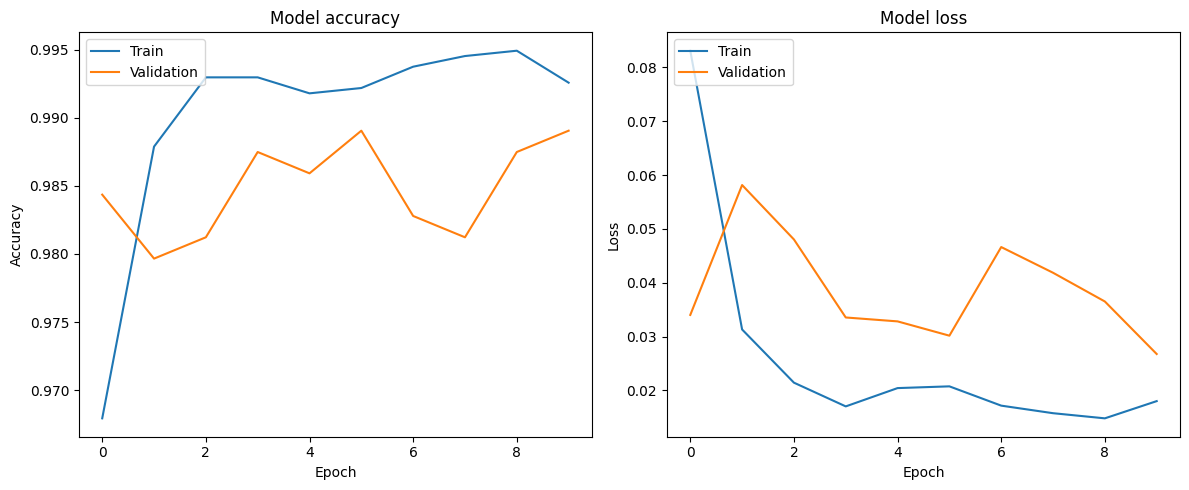

In [17]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()